# 02 — Returns and Risk (Exploratory Data Analysis)

Phase 2 of the Indian Equity AI project plan.

For each of the 5 stocks:
1. Weekly / monthly returns (calendar-based, on top of Phase 1's 1d/5d/20d/60d trading-day returns)
2. Rolling volatility (already computed in Phase 1)
3. Drawdown (rolling + max)
4. Beta vs NIFTY 50
5. Correlation vs NIFTY 50, sector index, and other stocks in the universe

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.ingestion.market_data import download_index_ohlcv
from src.preprocessing.clean import clean_ohlcv, validate_ohlcv
from src.features.returns import add_returns
from src.features.risk import add_drawdown, max_drawdown, period_returns, beta, correlation_matrix

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
from src.config import UNIVERSE  # Phase 14: centralized, now 50 stocks

SECTOR_INDEX = {
    "TCS": "^CNXIT",
    "INFY": "^CNXIT",
    "HDFCBANK": "^NSEBANK",
    # ITC (FMCG) and RELIANCE (conglomerate/energy) sector indices
    # have unreliable/near-empty history on Yahoo Finance -- see note below.
}

## Step 0: Load Phase 1 output

In [2]:
universe = pd.read_parquet(DATA_PROCESSED / "prices_daily.parquet")
assert validate_ohlcv(universe) == {
    "missing_values": 0,
    "duplicate_rows": 0,
    "non_positive_prices": 0,
    "negative_volume": 0,
    "high_below_low": 0,
}
universe.groupby("symbol")["date"].agg(["min", "max", "count"])

,min,max,count
symbol,,,
ADANIENT,2021-09-29,2026-09-28,1240
ADANIPORTS,2021-09-29,2026-09-28,1240
APOLLOHOSP,2021-09-29,2026-09-28,1240
ASIANPAINT,2021-09-29,2026-09-28,1240
AXISBANK,2021-09-29,2026-09-28,1240
BAJAJ-AUTO,2021-09-29,2026-09-28,1240
BAJAJFINSV,2021-09-29,2026-09-28,1240
BAJFINANCE,2021-09-29,2026-09-28,1240
BHARTIARTL,2021-09-29,2026-09-28,1240


## Step 1: Weekly and monthly returns

In [3]:
weekly = period_returns(universe, freq="W-FRI")
monthly = period_returns(universe, freq="ME")

print("Weekly return summary (std dev by symbol):")
display(weekly.groupby("symbol")["return"].std())
print("Monthly return summary (std dev by symbol):")
display(monthly.groupby("symbol")["return"].std())

Weekly return summary (std dev by symbol):


symbol
ADANIENT      0.068386
ADANIPORTS    0.049017
APOLLOHOSP    0.034907
ASIANPAINT    0.032869
AXISBANK      0.034637
BAJAJ-AUTO    0.034768
BAJAJFINSV    0.036117
BAJFINANCE    0.037133
BHARTIARTL    0.027140
BPCL          0.038766
BRITANNIA     0.027203
CIPLA         0.029732
COALINDIA     0.038867
DIVISLAB      0.039063
DMART         0.042702
DRREDDY       0.030416
EICHERMOT     0.038110
GRASIM        0.032136
HCLTECH       0.035823
HDFCBANK      0.027184
HDFCLIFE      0.033055
HEROMOTOCO    0.037645
HINDALCO      0.041782
HINDUNILVR    0.028006
ICICIBANK     0.027182
INDUSINDBK    0.045660
INFY          0.035551
ITC           0.028198
JSWSTEEL      0.032896
KOTAKBANK     0.027623
LT            0.033159
M&M           0.041057
MARUTI        0.033118
NESTLEIND     0.026135
NTPC          0.032246
ONGC          0.037361
POWERGRID     0.032446
RELIANCE      0.029446
SBILIFE       0.030147
SBIN          0.032188
SUNPHARMA     0.027033
TATACONSUM    0.029810
TATASTEEL     0.040605
TCS 

Monthly return summary (std dev by symbol):


symbol
ADANIENT      0.140196
ADANIPORTS    0.091310
APOLLOHOSP    0.076186
ASIANPAINT    0.074015
AXISBANK      0.071225
BAJAJ-AUTO    0.078105
BAJAJFINSV    0.085769
BAJFINANCE    0.086316
BHARTIARTL    0.055226
BPCL          0.086877
BRITANNIA     0.062509
CIPLA         0.057081
COALINDIA     0.074089
DIVISLAB      0.080901
DMART         0.084148
DRREDDY       0.061537
EICHERMOT     0.073328
GRASIM        0.064378
HCLTECH       0.081350
HDFCBANK      0.052294
HDFCLIFE      0.071650
HEROMOTOCO    0.082223
HINDALCO      0.095823
HINDUNILVR    0.060980
ICICIBANK     0.055672
INDUSINDBK    0.107381
INFY          0.074595
ITC           0.062025
JSWSTEEL      0.070202
KOTAKBANK     0.057723
LT            0.065386
M&M           0.076737
MARUTI        0.069763
NESTLEIND     0.062589
NTPC          0.068345
ONGC          0.076959
POWERGRID     0.065925
RELIANCE      0.056130
SBILIFE       0.066397
SBIN          0.073994
SUNPHARMA     0.063625
TATACONSUM    0.065898
TATASTEEL     0.084205
TCS 

## Step 2: Drawdown

In [4]:
universe = add_drawdown(universe)
mdd = max_drawdown(universe)
print("Maximum drawdown per stock over the 5-year window:")
display(mdd.sort_values())

Maximum drawdown per stock over the 5-year window:


symbol
TMPV         -0.757499
ADANIENT     -0.713466
INDUSINDBK   -0.622791
TCS          -0.564623
WIPRO        -0.552155
ADANIPORTS   -0.523370
INFY         -0.507276
HINDALCO     -0.498733
ITC          -0.492415
DIVISLAB     -0.487942
HCLTECH      -0.481630
TECHM        -0.465672
UPL          -0.462664
HEROMOTOCO   -0.435737
BAJAJFINSV   -0.426953
BAJAJ-AUTO   -0.423135
ASIANPAINT   -0.406845
TATASTEEL    -0.406045
DMART        -0.393172
APOLLOHOSP   -0.385363
HINDUNILVR   -0.373958
HDFCLIFE     -0.372031
ULTRACEMCO   -0.369702
BPCL         -0.368324
ONGC         -0.356723
COALINDIA    -0.344560
BAJFINANCE   -0.333623
GRASIM       -0.330250
NTPC         -0.327166
HDFCBANK     -0.321651
POWERGRID    -0.313586
JSWSTEEL     -0.311780
MARUTI       -0.306616
KOTAKBANK    -0.300436
TATACONSUM   -0.294955
CIPLA        -0.290449
BRITANNIA    -0.290232
LT           -0.288779
TITAN        -0.286278
SBILIFE      -0.281596
M&M          -0.280902
AXISBANK     -0.280270
RELIANCE     -0.274221
DRRE

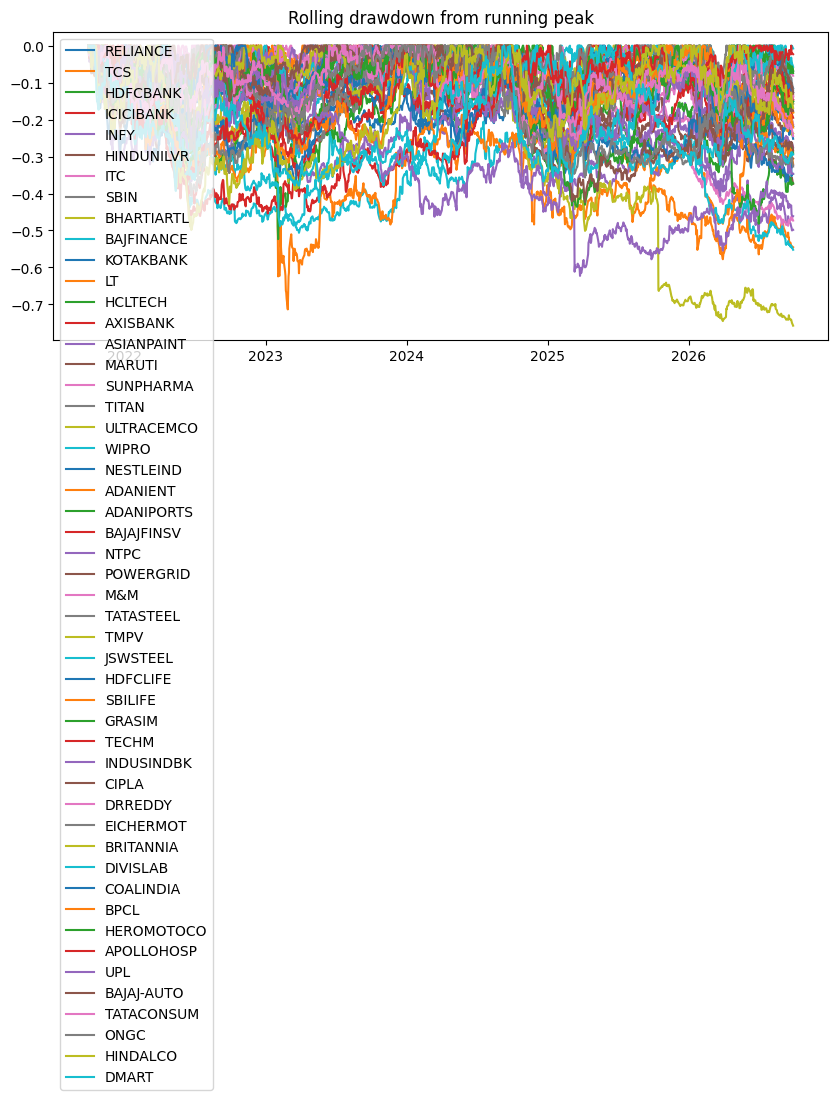

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
for symbol in UNIVERSE:
    subset = universe[universe["symbol"] == symbol].sort_values("date")
    ax.plot(subset["date"], subset["drawdown"], label=symbol)
ax.set_title("Rolling drawdown from running peak")
ax.legend()
plt.show()

## Step 3: Download NIFTY 50 and sector indices

In [6]:
nifty50 = clean_ohlcv(download_index_ohlcv("^NSEI", period="5y"))
nifty50 = add_returns(nifty50, periods=(1,))
print("NIFTY 50 rows:", len(nifty50))

sector_frames = {}
for sector_ticker in set(SECTOR_INDEX.values()):
    raw = download_index_ohlcv(sector_ticker, period="5y")
    if len(raw) < 250:  # need at least ~1 year of daily bars to be usable
        print(f"Skipping {sector_ticker}: only {len(raw)} rows returned by Yahoo Finance")
        continue
    cleaned = clean_ohlcv(raw)
    sector_frames[sector_ticker] = add_returns(cleaned, periods=(1,))
    print(sector_ticker, "rows:", len(cleaned))

NIFTY 50 rows: 1235


^CNXIT rows: 1234


^NSEBANK rows: 1234


**Note:** `^CNXFMCG` (ITC's sector) and `^CNXENERGY` (a proxy for RELIANCE) return almost no
historical data via Yahoo Finance's free chart API, so sector-relative correlation for
those two stocks is not available with this data source. NIFTY 50 correlation/beta and
cross-stock correlation are still computed for all 5 stocks.

## Step 4: Beta vs NIFTY 50

In [7]:
nifty_returns = nifty50.set_index("date")["return_1d"]

betas = {}
for symbol in UNIVERSE:
    stock = universe[universe["symbol"] == symbol].copy()
    stock = add_returns(stock, periods=(1,))
    stock_returns = stock.set_index("date")["return_1d"]
    betas[symbol] = beta(stock_returns, nifty_returns)

pd.Series(betas, name="beta_vs_nifty50")

RELIANCE      1.113125
TCS           0.810785
HDFCBANK      1.065090
ICICIBANK     0.966675
INFY          0.968127
HINDUNILVR    0.569739
ITC           0.678562
SBIN          1.163807
BHARTIARTL    0.790691
BAJFINANCE    1.291436
KOTAKBANK     0.958809
LT            1.194710
HCLTECH       0.878580
AXISBANK      1.081423
ASIANPAINT    0.725113
MARUTI        0.878067
SUNPHARMA     0.559939
TITAN         0.920575
ULTRACEMCO    1.021580
WIPRO         0.991716
NESTLEIND     0.520182
ADANIENT      1.728693
ADANIPORTS    1.587152
BAJAJFINSV    1.235747
NTPC          0.904799
POWERGRID     0.744201
M&M           1.189824
TATASTEEL     1.290911
TMPV          1.381122
JSWSTEEL      1.207417
HDFCLIFE      0.892950
SBILIFE       0.856040
GRASIM        1.088528
TECHM         0.975276
INDUSINDBK    1.245741
CIPLA         0.423357
DRREDDY       0.522431
EICHERMOT     1.021326
BRITANNIA     0.505121
DIVISLAB      0.636010
COALINDIA     0.872631
BPCL          1.100969
HEROMOTOCO    0.902228
APOLLOHOSP 

## Step 5: Correlation vs NIFTY 50, sector index, and other stocks

In [8]:
returns_wide = {}
for symbol in UNIVERSE:
    stock = universe[universe["symbol"] == symbol].copy()
    stock = add_returns(stock, periods=(1,))
    returns_wide[symbol] = stock.set_index("date")["return_1d"]

returns_wide["NIFTY50"] = nifty_returns
for sector_ticker, frame in sector_frames.items():
    returns_wide[sector_ticker] = frame.set_index("date")["return_1d"]

returns_wide_df = pd.DataFrame(returns_wide)
corr = correlation_matrix(returns_wide_df)
corr

,RELIANCE,TCS,HDFCBANK,ICICIBANK,INFY,HINDUNILVR,ITC,SBIN,BHARTIARTL,BAJFINANCE,...,APOLLOHOSP,UPL,BAJAJ-AUTO,TATACONSUM,ONGC,HINDALCO,DMART,NIFTY50,^CNXIT,^NSEBANK
RELIANCE,1.000000,0.266649,0.370009,0.344987,0.259172,0.212954,0.316076,0.433360,0.329736,0.374329,...,0.225193,0.324138,0.285247,0.278635,0.350873,0.359620,0.197782,0.688865,0.320805,0.504845
TCS,0.266649,1.000000,0.232638,0.207920,0.731946,0.198619,0.173996,0.194373,0.199390,0.229781,...,0.164420,0.229572,0.155629,0.263642,0.125975,0.216719,0.107449,0.495338,0.865078,0.275711
HDFCBANK,0.370009,0.232638,1.000000,0.489766,0.255740,0.231436,0.234345,0.408151,0.284404,0.430149,...,0.201721,0.301084,0.246200,0.246242,0.115804,0.266218,0.173043,0.699074,0.296941,0.776956
ICICIBANK,0.344987,0.207920,0.489766,1.000000,0.222457,0.201925,0.262020,0.513067,0.317058,0.421420,...,0.242010,0.276735,0.226092,0.246999,0.152039,0.259866,0.135991,0.662344,0.253189,0.778376
INFY,0.259172,0.731946,0.255740,0.222457,1.000000,0.196837,0.186594,0.172558,0.242416,0.249527,...,0.156557,0.249426,0.136780,0.255391,0.126641,0.241396,0.109478,0.512860,0.911240,0.284362
HINDUNILVR,0.212954,0.198619,0.231436,0.201925,0.196837,1.000000,0.346580,0.148555,0.166385,0.217883,...,0.192756,0.159928,0.219542,0.426202,-0.023716,0.089511,0.231212,0.383488,0.199024,0.283605
ITC,0.316076,0.173996,0.234345,0.262020,0.186594,0.346580,1.000000,0.279860,0.244009,0.270720,...,0.158309,0.233319,0.189645,0.325389,0.154332,0.205203,0.186414,0.463239,0.224721,0.348034
SBIN,0.433360,0.194373,0.408151,0.513067,0.172558,0.148555,0.279860,1.000000,0.282753,0.422327,...,0.204452,0.315932,0.253180,0.226564,0.308607,0.327891,0.164704,0.654045,0.230830,0.742263
BHARTIARTL,0.329736,0.199390,0.284404,0.317058,0.242416,0.166385,0.244009,0.282753,1.000000,0.270120,...,0.208915,0.278427,0.272304,0.258144,0.213503,0.264734,0.148131,0.508783,0.278023,0.381104
BAJFINANCE,0.374329,0.229781,0.430149,0.421420,0.249527,0.217883,0.270720,0.422327,0.270120,1.000000,...,0.284041,0.339132,0.254130,0.285717,0.122831,0.250533,0.260343,0.628440,0.294565,0.577932


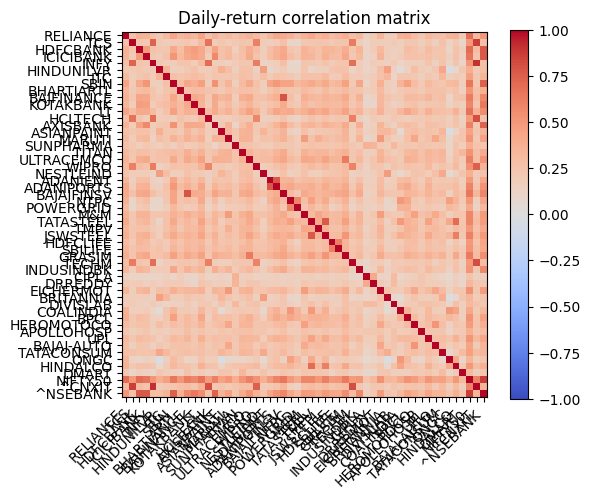

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
fig.colorbar(im)
ax.set_title("Daily-return correlation matrix")
plt.tight_layout()
plt.show()

## Summary: stock analytics report

In [10]:
report = pd.DataFrame({
    "max_drawdown": mdd,
    "beta_vs_nifty50": pd.Series(betas),
    "corr_vs_nifty50": corr.loc[UNIVERSE, "NIFTY50"],
})
report["weekly_return_std"] = weekly.groupby("symbol")["return"].std()
report["monthly_return_std"] = monthly.groupby("symbol")["return"].std()
report

,max_drawdown,beta_vs_nifty50,corr_vs_nifty50,weekly_return_std,monthly_return_std
ADANIENT,-0.713466,1.728693,0.494153,0.068386,0.140196
ADANIPORTS,-0.523370,1.587152,0.597893,0.049017,0.091310
APOLLOHOSP,-0.385363,0.695841,0.380585,0.034907,0.076186
ASIANPAINT,-0.406845,0.725113,0.451159,0.032869,0.074015
AXISBANK,-0.280270,1.081423,0.614437,0.034637,0.071225
BAJAJ-AUTO,-0.423135,0.774897,0.439776,0.034768,0.078105
BAJAJFINSV,-0.426953,1.235747,0.648559,0.036117,0.085769
BAJFINANCE,-0.333623,1.291436,0.628440,0.037133,0.086316
BHARTIARTL,-0.187682,0.790691,0.508783,0.027140,0.055226
BPCL,-0.368324,1.100969,0.528317,0.038766,0.086877


In [11]:
report.to_csv(DATA_PROCESSED / "stock_analytics_report.csv")
corr.to_csv(DATA_PROCESSED / "correlation_matrix.csv")
print("Saved:", DATA_PROCESSED / "stock_analytics_report.csv")
print("Saved:", DATA_PROCESSED / "correlation_matrix.csv")

Saved: D:\Practise\Stock Market Analysis\data\processed\stock_analytics_report.csv
Saved: D:\Practise\Stock Market Analysis\data\processed\correlation_matrix.csv
